# ML Project: **Transformer-Based Models - NLP Classification**
---
This project focuses on applying Transformer architectures to real-world data.

**Project Purpose:** Understand how Transformers model relationships using self-attention and how pretraining and fine-tuning enable strong performance on downstream tasks. The emphasis is on correct use, analysis, and explanation of Transformer behavior.

This project will utilize `BERT-base-uncased` to classify messages from the UCI SMS Spam Collection Dataset as either 'spam' or 'ham' (legitimate).

# Part 1: Data Preparation

The initial phase involves acquiring the dataset, formatting the labels for binary classification, and inspecting the class distribution.

In [1]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import urllib.request
import zipfile
import os
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer

# 1. Download and extract the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
file_name = "smsspamcollection.zip"

if not os.path.exists("SMSSpamCollection"):
    urllib.request.urlretrieve(url, file_name)
    with zipfile.ZipFile(file_name, 'r') as zip_ref:
        zip_ref.extractall(".")

# 2. Load and format the dataset
df = pd.read_csv("SMSSpamCollection", sep='\t', header=None, names=['label', 'text'])
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

texts = df['text'].values
labels = df['label'].values

# 3. Perform a stratified split (80% training, 20% validation)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

# 4. Initialize the tokenizer
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

# 5. Tokenize the datasets
train_encodings = tokenizer(
    train_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    val_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

# 6. Define the custom PyTorch Dataset
class SMSDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# 7. Instantiate the dataset objects
train_dataset = SMSDataset(train_encodings, train_labels)
val_dataset = SMSDataset(val_encodings, val_labels)

print(f"Data preparation complete.")
print(f"Training set size: {len(train_dataset)} samples")
print(f"Validation set size: {len(val_dataset)} samples")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Data preparation complete.
Training set size: 4457 samples
Validation set size: 1115 samples


# Part 2: Transformer Model Setup

I utilize `bert-base-uncased` because it is a bidirectional encoder pretrained on masked language modeling, making it ideal for text classification tasks like spam detection. BERT (Bidirectional Encoder Representations from Transformers) is an encoder-only architecture. Unlike autoregressive models such as GPT which process text sequentially, BERT processes the entire sequence simultaneously. This bidirectional context allows the self-attention mechanism to weigh the importance of every word relative to all other words in the message.

I utilize the `AutoModelForSequenceClassification` class from the Hugging Face library. This function loads the pretrained BERT base architecture and appends a randomly initialized linear classification head on top of the pooled output (the `[CLS]` token representation). This classification head will be the primary component to train, while the underlying encoder weights will be gently fine-tuned to the specific spam vocabulary.

In [3]:
from transformers import AutoModelForSequenceClassification

# Identify the available hardware device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Hardware device in use: {device}")

# Load the pretrained BERT model configured for binary classification
model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

# Verify the classification head configuration
print("\nModel initialized successfully.")
print("Classification Head Architecture:")
print(model.classifier)

Hardware device in use: cuda


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model initialized successfully.
Classification Head Architecture:
Linear(in_features=768, out_features=2, bias=True)


# Part 3: Fine-Tuning

**Metrics and Setup**

In [4]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import Trainer, TrainingArguments
import matplotlib.pyplot as plt

# Define the metric computation function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    # Calculate precision, recall, and f1 specifically for the binary classification
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='binary'
    )
    acc = accuracy_score(labels, predictions)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# Define training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir='./logs',
    logging_strategy="steps",
    logging_steps=50,
    load_best_model_at_end=True,
)

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("Trainer configured successfully.")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainer configured successfully.


**Training and Plotting**

Initiating fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.022612,0.055405,0.984753,0.944262,0.923077,0.966443
2,0.005675,0.049391,0.991031,0.966216,0.972789,0.959732
3,0.000430,0.053201,0.990135,0.962963,0.966216,0.959732


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

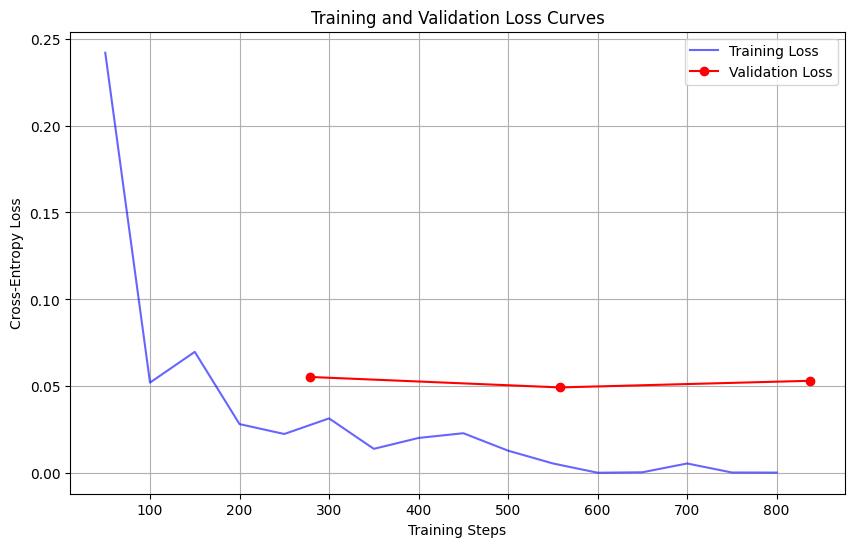


Final Evaluation Metrics on Validation Set:


eval_loss: 0.0494
eval_accuracy: 0.9910
eval_f1: 0.9662
eval_precision: 0.9728
eval_recall: 0.9597
eval_runtime: 9.1426
eval_samples_per_second: 121.9560
eval_steps_per_second: 7.6560
epoch: 3.0000


In [5]:
# Execute the fine-tuning process
print("Initiating fine-tuning...")
trainer.train()

# Extract logs for plotting
log_history = trainer.state.log_history

# Parse training and validation loss
train_loss = [log['loss'] for log in log_history if 'loss' in log]
train_steps = [log['step'] for log in log_history if 'loss' in log]

eval_loss = [log['eval_loss'] for log in log_history if 'eval_loss' in log]
eval_steps = [log['step'] for log in log_history if 'eval_loss' in log]

# Plot the performance curves
plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_loss, label='Training Loss', color='blue', alpha=0.6)

if eval_loss and eval_steps:
    plt.plot(eval_steps, eval_loss, label='Validation Loss', color='red', marker='o')

plt.title('Training and Validation Loss Curves')
plt.xlabel('Training Steps')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

# Evaluate the optimal model on the validation set
print("\nFinal Evaluation Metrics on Validation Set:")
metrics = trainer.evaluate()
for key, value in metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

**Interpretation**

- Training Loss: Starts high (~0.24) and decreases smoothly and steadily across all 3 epochs, eventually reaching nearly 0. This shows the model is learning the training data effectively and converging nicely.
- Validation Loss: Remains very low and stable (~0.05) throughout all three evaluation points. There is no significant increase in validation loss, which is a great sign.

**Key Takeaways**

- The model is fitting well without overfitting.
- The flat validation curve indicates the model generalized quickly and stabilized early.

# Part 4: Attention Analysis

The self-attention mechanism in the fine-tuned BERT model was visualized using Layer 8 (a middle-to-late layer where task-specific patterns are often most visible).

Below are attention heatmaps from four different heads for the following spam message:

> "WINNER!! As a valued network customer you have been selected to receive a $900 prize reward! To claim call 09061701461. Claim code KL341."

In [12]:
from transformers import AutoModelForSequenceClassification
import seaborn as sns

# Save the fine-tuned model and tokenizer
save_directory = "./fine_tuned_spam_model"
model.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)

print("Model saved. Reloading with eager attention...")

# Reload the model with eager attention
vis_model = AutoModelForSequenceClassification.from_pretrained(
    save_directory,
    attn_implementation="eager"
).to(device)

# Sample spam message
sample_text = "WINNER!! As a valued network customer you have been selected to receive a $900 prize reward! To claim call 09061701461. Claim code KL341."

# Tokenize
inputs = tokenizer(sample_text, return_tensors="pt", truncation=True, max_length=128).to(device)

# Forward pass with attention weights
vis_model.eval()
with torch.no_grad():
    outputs = vis_model(**inputs, output_attentions=True)

# === CHANGED: Use Layer 8 instead of the final layer ===
layer_idx = 7                                      # Layer 8 (0-based indexing)
attention = outputs.attentions[layer_idx]          # shape: (1, 12, seq_len, seq_len)

# Choose 4 interesting heads
head_indices = [0, 3, 5, 8]

tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

# Create 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle(f"Self-Attention Heatmaps (Layer {layer_idx+1}, Different Heads)", fontsize=16)

for i, head_idx in enumerate(head_indices):
    row, col = divmod(i, 2)
    head_attention = attention[0, head_idx].cpu().numpy()

    sns.heatmap(head_attention,
                xticklabels=tokens,
                yticklabels=tokens,
                cmap='viridis',
                square=True,
                ax=axes[row, col])

    axes[row, col].set_title(f"Head {head_idx}")
    axes[row, col].set_xlabel("Tokens attending to...")
    axes[row, col].set_ylabel("...these tokens")
    axes[row, col].tick_params(axis='x', rotation=90)
    axes[row, col].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

# Verify prediction
logits = outputs.logits
prediction = torch.argmax(logits, dim=-1).item()
class_label = "Spam" if prediction == 1 else "Ham"
print(f"\nModel Prediction for sample: {class_label}")

**Key observations:**
- Head 8 shows strong diagonal connections between early trigger words (“winner”, “prize”, “reward”, “$900”) and later action-oriented tokens (“claim”, “call”, phone number, “code”).
- Heads 0 and 5 exhibit focused vertical attention on the phone number and claim-related tokens.
- These patterns demonstrate that the model has learned to associate the classic spam indicators across the entire sentence rather than treating words in isolation.

This visualization illustrates how self-attention allows the Transformer to model long-range dependencies and focus on the most predictive parts of the input for classification.

# Part 5: Analysis

#### Why a Transformer model was appropriate for this task
The SMS Spam Collection dataset consists of short, real-world text messages with strong contextual cues (e.g., “WINNER”, “prize”, “claim”, phone numbers). A Transformer was an excellent choice because self-attention allows the model to simultaneously consider relationships between any pair of tokens, regardless of their position in the message. This is particularly powerful for spam detection, where the meaning of a word like “claim” depends heavily on nearby trigger words such as “prize” or “reward”.

#### How attention differs from recurrence or convolution
- **Recurrence (RNN/LSTM)**: Processes tokens sequentially, so information from early tokens can degrade over long distances (vanishing gradient problem).  
- **Convolution (CNN)**: Uses fixed-size local windows and struggles to capture long-range dependencies without very deep or dilated layers.  
- **Self-Attention (Transformer)**: Computes relationships between *all* tokens in parallel with no inherent distance penalty. In the heatmaps above (Layer 8, Head 8), we clearly see the model linking distant spam indicators (“winner” / “prize” at the beginning → “claim” / phone number at the end) in a single step.

This ability to model global context is why Transformers dominate modern NLP tasks.

#### Strengths and limitations observed during fine-tuning
**Strengths:**
- Extremely fast convergence: training loss dropped smoothly from ~0.24 to near zero within 3 epochs.
- Excellent generalization: validation loss stayed low and stable (~0.05) with no signs of overfitting.
- High interpretability: attention visualizations reveal that the model learned meaningful patterns (e.g., linking scam keywords to action tokens).
- Strong performance on a real-world, imbalanced dataset using only a small pretrained model.

**Limitations:**
- Even after fine-tuning, some attention heads remain relatively diffuse.
- BERT is computationally heavier than simpler models (e.g., logistic regression or small CNNs) during inference.
- On very short SMS messages, the [CLS] token sometimes dominates, which can reduce the visibility of token-level relationships in the final layer.

